# Анализ поиска в Яндекс Картинках

In [3]:
from pathlib import Path

import pandas as pd
from pandasql import sqldf

import numpy as np

pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 300)
pd.set_option('display.min_rows', 300)
pd.set_option('display.max_colwidth', 200)
pd.set_option('display.width', 220)

# Предполагаю, что файл data.tsv лежит в той же папке, что и ноутбук.
base_dir = Path.cwd()
data_path = base_dir / "data.tsv"

df = pd.read_csv(
    data_path,
    sep="	",
    header=None,
    names=["query", "ts", "platform"],
    encoding="utf-8",
)
df["query"] = df["query"].astype(str).str.strip()
df["query_norm"] = df["query"].str.lower()
df["dt"] = pd.to_datetime(df["ts"], unit="s", utc=True).dt.tz_convert("Europe/Moscow")
df["date"] = df["dt"].dt.date.astype(str)
df["hour"] = df["dt"].dt.hour

def q(sql: str):
    return sqldf(sql, {"df": df})

df.head()

,query,ts,platform,query_norm,dt,date,hour
0,малевич картины,1631806465,desktop,малевич картины,2021-09-16 18:34:25+03:00,2021-09-16,18
1,психология,1631781583,touch,психология,2021-09-16 11:39:43+03:00,2021-09-16,11
2,с днём рождения лена,1631771563,touch,с днём рождения лена,2021-09-16 08:52:43+03:00,2021-09-16,8
3,зверополис фильмы,1631787599,touch,зверополис фильмы,2021-09-16 13:19:59+03:00,2021-09-16,13
4,алабай собака фото,1631786645,touch,алабай собака фото,2021-09-16 13:04:05+03:00,2021-09-16,13


## 1. Диапазон данных

In [5]:
summary_sql = '''
SELECT
    MIN(date) AS min_date,
    MAX(date) AS max_date,
    COUNT(*) AS total_queries,
    COUNT(DISTINCT date) AS total_days
FROM df
'''

summary_sql = q(summary_sql)
summary_sql

,min_date,max_date,total_queries,total_days
0,2021-09-01,2021-09-21,1114365,21


## 2. Кол-во запросов "ютуб" по платформам

In [7]:
youtube_sql = '''
SELECT
    platform,
    COUNT(*) AS youtube_queries
FROM df
WHERE query_norm = 'ютуб'
GROUP BY platform
ORDER BY platform
'''

q(youtube_sql)

,platform,youtube_queries
0,desktop,718
1,touch,611


## 3. Топ-10 запросов по платформам

In [9]:
top10_sql = '''
WITH base AS (
    SELECT
        platform,
        query,
        COUNT(*) AS query_count
    FROM df
    GROUP BY platform, query
),
ranked AS (
    SELECT
        *,
        ROW_NUMBER() OVER (
            PARTITION BY platform
            ORDER BY query_count DESC, query
        ) AS rn
    FROM base
)
SELECT
    platform,
    rn AS rank,
    query,
    query_count
FROM ranked
WHERE rn <= 10
ORDER BY platform, rank
'''

q(top10_sql)

,platform,rank,query,query_count
0,desktop,1,календарь 2021,2804
1,desktop,2,таблица менделеева,2631
2,desktop,3,картинки,1647
3,desktop,4,английский алфавит,1293
4,desktop,5,обои на рабочий стол,1143
5,desktop,6,Одноклассники (социальная сеть),1116
6,desktop,7,таблица квадратов,877
7,desktop,8,алфавит,874
8,desktop,9,таблица умножения,867
9,desktop,10,карта мира,795


## Отличия:

`desktop` - значительно связан с учебой и работой

`touch` - значительно свзяан с поздравлениями, развлечениями и быстрыми повседневными задачами

## 4. Отличия трафика в течение дня

In [12]:
hourly_sql = '''
WITH hourly_base AS (
    SELECT
        platform,
        hour,
        COUNT(*) AS query_count
    FROM df
    GROUP BY platform, hour
),
platform_totals AS (
    SELECT
        platform,
        COUNT(*) AS platform_total
    FROM df
    GROUP BY platform
 )
SELECT
    hb.platform,
    hb.hour,
    hb.query_count,
    ROUND(1.0 * hb.query_count / pt.platform_total, 4) AS share
FROM hourly_base hb
JOIN platform_totals pt
    ON hb.platform = pt.platform
ORDER BY hb.platform, hb.hour
'''

hourly = q(hourly_sql)
hourly.head()

,platform,hour,query_count,share
0,desktop,0,6232,0.0161
1,desktop,1,3612,0.0093
2,desktop,2,2477,0.0064
3,desktop,3,2234,0.0058
4,desktop,4,2805,0.0072


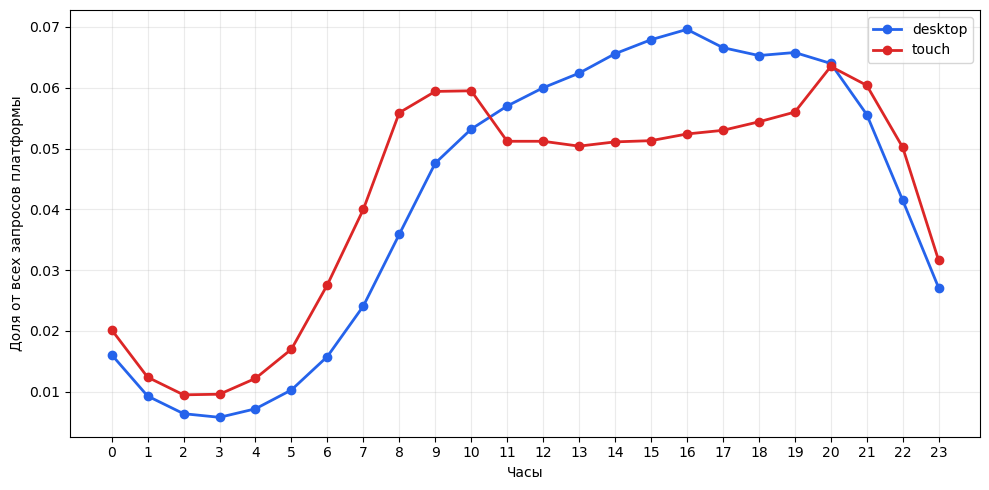

In [13]:
from pathlib import Path
import matplotlib.pyplot as plt

img_dir = Path.cwd() / 'img'
img_dir.mkdir(exist_ok=True)

plt.figure(figsize=(10, 5))
for platform, color in [('desktop', '#2563eb'), ('touch', '#dc2626')]:
    part = hourly[hourly['platform'] == platform]
    plt.plot(part['hour'], part['share'], marker='o', linewidth=2, label=platform, color=color)

plt.xlabel('Часы')
plt.ylabel('Доля от всех запросов платформы')
plt.xticks(range(24))
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig(img_dir / 'hourly_traffic.png', dpi=160, bbox_inches='tight')
plt.show()

### Пики:
`desktop`: **16:00**, доля **6.96%** - выглядит как рабочий/учебный паттерн

`touch`: **20:00**, доля **6.35%** - сильнее растет вечером, что похоже на личное и развлекательное потребление

## 5. Контрастные тематики

### Сделаем выгрузку query с метриками с сортировкой по total_count 

In [17]:
frequent_queries_sql = '''
WITH query_platform AS (
    SELECT
        query,
        platform,
        COUNT(*) AS query_count
    FROM df
    GROUP BY query, platform
),
query_totals AS (
    SELECT
        query,
        SUM(query_count) AS total_count
    FROM query_platform
    GROUP BY query
),
platform_totals AS (
    SELECT
        platform,
        COUNT(*) AS platform_total
    FROM df
    GROUP BY platform
),
pivoted AS (
    SELECT
        qt.query,
        qt.total_count,
        COALESCE(MAX(CASE WHEN qp.platform = 'desktop' THEN qp.query_count END), 0) AS desktop_count,
        COALESCE(MAX(CASE WHEN qp.platform = 'touch' THEN qp.query_count END), 0) AS touch_count
    FROM query_totals qt
    LEFT JOIN query_platform qp
        ON qt.query = qp.query
    WHERE qt.total_count >= 300
    GROUP BY qt.query, qt.total_count
)
SELECT
    p.query,
    p.total_count,
    p.desktop_count,
    p.touch_count,
    ROUND(1.0 * p.desktop_count / p.total_count, 4) AS desktop_share_in_query,
    ROUND(1.0 * p.touch_count / p.total_count, 4) AS touch_share_in_query,
    ROUND(1.0 * p.desktop_count / d.platform_total, 4) AS desktop_share_of_platform,
    ROUND(1.0 * p.touch_count / t.platform_total, 4) AS touch_share_of_platform
FROM pivoted p
CROSS JOIN (SELECT platform_total FROM platform_totals WHERE platform = 'desktop') d
CROSS JOIN (SELECT platform_total FROM platform_totals WHERE platform = 'touch') t
ORDER BY p.total_count DESC, p.query
'''

frequent_queries = q(frequent_queries_sql)
frequent_queries.head(300)

,query,total_count,desktop_count,touch_count,desktop_share_in_query,touch_share_in_query,desktop_share_of_platform,touch_share_of_platform
0,с днём рождения женщине,5404,501,4903,0.0927,0.9073,0.0013,0.0068
1,календарь 2021,5041,2804,2237,0.5562,0.4438,0.0072,0.0031
2,таблица менделеева,4728,2631,2097,0.5565,0.4435,0.0068,0.0029
3,с днём рождения,4252,285,3967,0.0670,0.9330,0.0007,0.0055
4,с днём рождения мужчине,3955,332,3623,0.0839,0.9161,0.0009,0.0050
5,игры,3533,700,2833,0.1981,0.8019,0.0018,0.0039
6,с днем рождения,3446,441,3005,0.1280,0.8720,0.0011,0.0041
7,погода,3341,501,2840,0.1500,0.8500,0.0013,0.0039
8,картинки,3305,1647,1658,0.4983,0.5017,0.0042,0.0023
9,фильмы,3215,469,2746,0.1459,0.8541,0.0012,0.0038


### Распределим вручную запросы с 300+ total_count по темам (294 запроса)

In [19]:
category_rules = pd.DataFrame([
    ('Поздравления и праздники', 'с днём рождения женщине'),
    ('Поздравления и праздники', 'с днём рождения'),
    ('Поздравления и праздники', 'с днём рождения мужчине'),
    ('Поздравления и праздники', 'с днем рождения'),
    ('Поздравления и праздники', 'доброе утро'),
    ('Поздравления и праздники', 'с 1 сентября'),
    ('Поздравления и праздники', 'доброе утро картинки'),
    ('Поздравления и праздники', 'с днём рождения девушке'),
    ('Поздравления и праздники', 'поздравления с днём рождения женщине'),
    ('Поздравления и праздники', '1 сентября'),
    ('Поздравления и праздники', 'открытки с днём рождения женщине'),
    ('Поздравления и праздники', 'поздравления с днём рождения'),
    ('Поздравления и праздники', 'поздравления с днём рождения мужчине'),
    ('Поздравления и праздники', 'с добрым утром'),
    ('Поздравления и праздники', 'с днем знаний'),
    ('Поздравления и праздники', '1 сентября картинки'),
    ('Поздравления и праздники', 'рождество пресвятой богородицы'),
    ('Поздравления и праздники', 'открытки с днём рождения'),
    ('Поздравления и праздники', 'доброе утро картинки позитивные'),
    ('Поздравления и праздники', 'открытки с днём рождения мужчине'),
    ('Поздравления и праздники', 'с днем рождения мужчине'),
    ('Поздравления и праздники', 'цветы'),
    ('Поздравления и праздники', 'с днем рождения женщине'),
    ('Поздравления и праздники', 'с днём рождения женщине открытки'),
    ('Поздравления и праздники', 'открытка с днём рождения женщине'),
    ('Поздравления и праздники', 'спокойной ночи'),
    ('Поздравления и праздники', 'картинки с добрым утром'),
    ('Поздравления и праздники', 'с рождеством пресвятой богородицы'),
    ('Поздравления и праздники', 'картинки с днём рождения'),
    ('Поздравления и праздники', 'с днём рождения женщине красивые'),
    ('Поздравления и праздники', 'спасибо за внимание'),
    ('Поздравления и праздники', 'поздравление с днём рождения женщине'),
    ('Поздравления и праздники', 'с добрым утром картинки'),
    ('Поздравления и праздники', 'поздравления с днём рождения женщине красивые'),
    ('Поздравления и праздники', 'поздравление с 1 сентября'),
    ('Поздравления и праздники', 'картинки с днём рождения женщине'),
    ('Поздравления и праздники', 'хорошего дня'),
    ('Поздравления и праздники', 'доброе осеннее утро'),
    ('Поздравления и праздники', 'с днём рождения мужчине открытки'),
    ('Поздравления и праздники', 'открытки с добрым утром'),
    ('Поздравления и праздники', 'спокойной ночи картинки'),
    ('Поздравления и праздники', 'открытка с днём рождения'),
    ('Поздравления и праздники', 'День знаний'),
    ('Поздравления и праздники', 'поздравление с днем рождения'),
    ('Поздравления и праздники', 'с 1 сентября картинки'),
    ('Поздравления и праздники', 'открытки с днём рождения женщине красивые'),
    ('Поздравления и праздники', 'с рождеством богородицы'),
    ('Поздравления и праздники', 'открытки с 1 сентября'),
    ('Поздравления и праздники', 'открытка с днём рождения мужчине'),
    ('Поздравления и праздники', 'с 1 сентября поздравления'),
    ('Поздравления и праздники', 'с днём рождения мужчине прикольные'),
    ('Поздравления и праздники', 'с годовщиной свадьбы'),
    ('Поздравления и праздники', 'С Днем знаний'),
    ('Поздравления и праздники', 'поздравление с днём рождения мужчине'),
    ('Поздравления и праздники', 'с днём ангела наталья'),
    ('Поздравления и праздники', 'с первым сентября картинки'),
    ('Поздравления и праздники', 'рождество пресвятой богородицы поздравления'),
    ('Поздравления и праздники', 'с добрым осенним утром'),
    ('Поздравления и праздники', 'доброе утро картинки красивые'),
    ('Поздравления и праздники', 'картинки с днём рождения мужчине'),
    ('Поздравления и праздники', 'поздравления с днём рождения девушке'),
    ('Поздравления и праздники', 'доброе утро осень'),
    ('Поздравления и праздники', 'С днем рождения'),
    ('Поздравления и праздники', 'с первым сентября'),
    ('Поздравления и праздники', 'с добрым утром и хорошим днём'),
    ('Поздравления и праздники', 'с днем знаний картинки'),
    

    ('Справка и Образование', 'календарь 2021'),
    ('Справка и Образование', 'погода'),
    ('Справка и Образование', 'английский алфавит'),
    ('Справка и Образование', 'алфавит'),
    ('Справка и Образование', 'формулы сокращенного умножения'),
    ('Справка и Образование', 'таблица квадратов'),
    ('Справка и Образование', 'таблица умножения'),
    ('Справка и Образование', 'алфавит русский'),
    ('Справка и Образование', 'знаки зодиака'),
    ('Справка и Образование', 'календарь 2022'),
    ('Справка и Образование', 'алфавит английский'),
    ('Справка и Образование', 'гимн россии текст'),
    ('Справка и Образование', 'римские цифры'),
    ('Справка и Образование', 'календарь на 2022 год с праздниками и выходными'),
    ('Справка и Образование', 'календарь'),
    ('Справка и Образование', 'знаки зодиака по месяцам'),
    ('Справка и Образование', 'немецкий алфавит'),
    ('Справка и Образование', 'производственный календарь 2021'),
    ('Справка и Образование', 'пословицы'),
    ('Справка и Образование', 'аксолотль'),
    ('Справка и Образование', 'таблица степеней'),
    ('Справка и Образование', 'флаг россии'),
    ('Справка и Образование', 'гимн россии'),
    ('Справка и Образование', 'таблица менделеева'),
    ('Справка и Образование', 'психология'),
    ('Справка и Образование', 'наука'),
    ('Справка и Образование', 'технологии'),
    ('Справка и Образование', 'литература'),
    ('Справка и Образование', 'история'),
    ('Справка и Образование', 'образование'),
    ('Справка и Образование', 'падежи'),
    ('Справка и Образование', 'дискриминант'),
    ('Справка и Образование', 'спряжение глаголов'),
    ('Справка и Образование', 'синтаксический разбор предложения'),
    ('Справка и Образование', 'теорема виета'),
    ('Справка и Образование', 'космос'),
    ('Справка и Образование', 'тригонометрические формулы'),
    ('Справка и Образование', 'фонетический разбор слова'),
    ('Справка и Образование', 'человек'),
    ('Справка и Образование', 'морфологический разбор'),
    ('Справка и Образование', 'расписание уроков шаблоны распечатать'),
    ('Справка и Образование', 'морфологический разбор слова'),
    ('Справка и Образование', 'производственный календарь на 2022'),
    ('Справка и Образование', 'солнечная система'),
    ('Справка и Образование', 'тригонометрический круг'),
    ('Справка и Образование', 'скороговорки'),
    ('Справка и Образование', 'фон для презентации'),
    ('Справка и Образование', 'календарь сентябрь 2021'),
    ('Справка и Образование', 'формула дискриминанта'),
    ('Справка и Образование', 'а4'),
    ('Справка и Образование', 'расписание уроков'),
    ('Справка и Образование', 'таблица производных'),
    ('Справка и Образование', 'как завязать галстук'),
    ('Справка и Образование', 'пирамида маслоу'),
    ('Справка и Образование', 'календарь учителя на 2021-2022 учебный год для учителя распечатать'),
    ('Справка и Образование', 'клавиатура'),
    ('Справка и Образование', 'крайние точки россии'),
    ('Справка и Образование', 'present simple'),
    ('Справка и Образование', 'дни недели на английском'),
    ('Справка и Образование', 'отче наш'),
    ('Справка и Образование', 'части речи'),
    ('Справка и Образование', 'халва карта логотип'),
    ('Справка и Образование', 'дорожные знаки'),
    ('Справка и Образование', 'синтаксический разбор'),
    ('Справка и Образование', 'загадки для детей'),
    ('Справка и Образование', 'русский алфавит'),
    ('Справка и Образование', 'снилс'),
    ('Справка и Образование', 'свойства степеней'),
    ('Справка и Образование', 'календарь 2022 с праздниками и выходными'),
    ('Справка и Образование', 'производственный календарь 2022'),
    ('Справка и Образование', 'таблица интегралов'),
    ('Справка и Образование', 'времена в английском языке'),
    ('Справка и Образование', 'морфологический разбор глагола'),
    ('Справка и Образование', 'неправильные глаголы английского языка'),
    ('Справка и Образование', 'инн'),
    ('Справка и Образование', 'латинский алфавит'),
    ('Справка и Образование', 'люди'),
    

    ('Медиа, фото и развлечения', 'игры'),
    ('Медиа, фото и развлечения', 'картинки'),
    ('Медиа, фото и развлечения', 'фильмы'),
    ('Медиа, фото и развлечения', 'музыка'),
    ('Медиа, фото и развлечения', 'спорт'),
    ('Медиа, фото и развлечения', 'путешествия'),
    ('Медиа, фото и развлечения', 'кино'),
    ('Медиа, фото и развлечения', 'обои на телефон'),
    ('Медиа, фото и развлечения', 'обои на рабочий стол'),
    ('Медиа, фото и развлечения', 'аниме'),
    ('Медиа, фото и развлечения', 'фото'),
    ('Медиа, фото и развлечения', 'ютуб'),
    ('Медиа, фото и развлечения', 'белый фон'),
    ('Медиа, фото и развлечения', 'черный фон'),
    ('Медиа, фото и развлечения', 'рисунки для срисовки'),
    ('Медиа, фото и развлечения', 'инстасамка'),
    ('Медиа, фото и развлечения', 'загадки'),
    ('Медиа, фото и развлечения', 'рисунки'),
    ('Медиа, фото и развлечения', 'осень'),
    ('Медиа, фото и развлечения', '13 карт'),
    ('Медиа, фото и развлечения', 'раскраски'),
    ('Медиа, фото и развлечения', 'обои'),
    ('Медиа, фото и развлечения', 'видео'),
    ('Медиа, фото и развлечения', 'наруто'),
    ('Медиа, фото и развлечения', 'YouTube'),
    ('Медиа, фото и развлечения', 'фон'),
    ('Медиа, фото и развлечения', 'токийские мстители'),
    ('Медиа, фото и развлечения', 'валя карнавал'),
    ('Медиа, фото и развлечения', 'macro photography of nature'),
    ('Медиа, фото и развлечения', 'раскраски для девочек'),
    ('Медиа, фото и развлечения', 'video'),
    ('Медиа, фото и развлечения', 'картинки на рабочий стол'),
    ('Медиа, фото и развлечения', 'мемы'),
    ('Медиа, фото и развлечения', 'моргенштерн'),
    ('Медиа, фото и развлечения', 'раскраска'),
    ('Медиа, фото и развлечения', 'Аниме Арты'),
    ('Медиа, фото и развлечения', 'раскраска для девочек'),
    ('Медиа, фото и развлечения', 'жан-поль бельмондо'),
    ('Медиа, фото и развлечения', 'осень картинки'),
    ('Медиа, фото и развлечения', 'Рыжий Цвет Волос'),
    ('Медиа, фото и развлечения', 'корги'),
    ('Медиа, фото и развлечения', 'майнкрафт'),
    ('Медиа, фото и развлечения', 'картинки для срисовки'),
    ('Медиа, фото и развлечения', 'раскраски для девочек распечатать'),
    ('Медиа, фото и развлечения', 'майки токийские мстители'),
    ('Медиа, фото и развлечения', 'поделки из природного материала'),
    ('Медиа, фото и развлечения', 'Minecraft'),
    ('Медиа, фото и развлечения', 'чёрный фон без ничего'),
    ('Медиа, фото и развлечения', 'Кошки Маленькие'),
    ('Медиа, фото и развлечения', 'путин'),
    ('Медиа, фото и развлечения', 'раскраски для мальчиков'),
    ('Медиа, фото и развлечения', 'картинка'),
    ('Медиа, фото и развлечения', 'бельмондо'),
    ('Медиа, фото и развлечения', 'рисунки по клеточкам'),
    ('Медиа, фото и развлечения', 'ankha'),
    ('Медиа, фото и развлечения', 'Поп Арт'),
    ('Медиа, фото и развлечения', 'котики'),
    ('Медиа, фото и развлечения', 'рисунки для срисовки лёгкие'),
    ('Медиа, фото и развлечения', 'дед инсайд'),
    ('Медиа, фото и развлечения', 'гачимучи'),
    ('Медиа, фото и развлечения', '3 сентября шуфутинский'),
    ('Медиа, фото и развлечения', '3 сентября'),
    ('Медиа, фото и развлечения', 'красивые картинки'),
    ('Медиа, фото и развлечения', 'природа'),
    ('Медиа, фото и развлечения', 'обои на телефон эстетика'),
    ('Медиа, фото и развлечения', 'шуфутинский'),
    ('Медиа, фото и развлечения', 'дюна'),
    ('Медиа, фото и развлечения', 'чёрный фон'),
    ('Медиа, фото и развлечения', 'шуфутинский 3 сентября'),
    ('Медиа, фото и развлечения', 'вару'),
    ('Медиа, фото и развлечения', 'море'),
    ('Медиа, фото и развлечения', 'Космос Арт'),
    ('Медиа, фото и развлечения', 'итачи'),
    ('Медиа, фото и развлечения', 'Жан-Поль Бельмондо'),
    ('Медиа, фото и развлечения', 'меган фокс'),
    ('Медиа, фото и развлечения', 'геншин импакт'),
    ('Медиа, фото и развлечения', 'поп ит'),
    ('Медиа, фото и развлечения', 'яой'),
    ('Медиа, фото и развлечения', 'доберман'),
    ('Медиа, фото и развлечения', 'кот'),
    ('Медиа, фото и развлечения', 'осенние поделки'),
    ('Медиа, фото и развлечения', 'собака'),
    ('Медиа, фото и развлечения', 'аватарки'),
    ('Медиа, фото и развлечения', 'пик 13 карт'),
    ('Медиа, фото и развлечения', 'Картины'),
    ('Медиа, фото и развлечения', 'обои на рабочий стол красивые большие на весь экран бесплатно'),


    ('Покупки, стиль и бренды', 'мода'),
    ('Покупки, стиль и бренды', 'айфон 13'),
    ('Покупки, стиль и бренды', 'iphone 13'),
    ('Покупки, стиль и бренды', 'девушка'),
    ('Покупки, стиль и бренды', 'Узбекские Женщины'),
    ('Покупки, стиль и бренды', 'маникюр осень 2021'),
    ('Покупки, стиль и бренды', 'маникюр'),
    ('Покупки, стиль и бренды', 'дизайн ногтей'),
    ('Покупки, стиль и бренды', 'девушки'),
    ('Покупки, стиль и бренды', 'осенний маникюр'),
    ('Покупки, стиль и бренды', 'осенний маникюр 2021'),
    ('Покупки, стиль и бренды', 'маникюр 2021'),
    ('Покупки, стиль и бренды', 'красивые девушки'),
    ('Покупки, стиль и бренды', 'айфон 12'),
    ('Покупки, стиль и бренды', 'айфон 11'),
    ('Покупки, стиль и бренды', 'женщина'),
    ('Покупки, стиль и бренды', 'мерседес'),
    ('Покупки, стиль и бренды', 'Спорткары'),
    ('Покупки, стиль и бренды', 'мужчина'),
    ('Покупки, стиль и бренды', '13 айфон'),
    ('Покупки, стиль и бренды', 'дизайн ногтей 2021'),
    ('Покупки, стиль и бренды', 'ногти дизайн'),
    ('Покупки, стиль и бренды', 'маникюр дизайн'),
    ('Покупки, стиль и бренды', 'бмв'),

    
    ('Карты и навигация', 'карта метро Москвы'),
    ('Карты и навигация', 'карта метро'),
    ('Карты и навигация', 'карта метро москвы'),
    ('Карты и навигация', 'схема метро москвы'),
    ('Карты и навигация', 'карта мира'),
    ('Карты и навигация', 'карта россии'),
    ('Карты и навигация', 'карта России'),
    ('Карты и навигация', 'метро спб'),
    ('Карты и навигация', 'схема метро'),
    ('Карты и навигация', 'метро москвы схема'),
    ('Карты и навигация', 'карта метро москвы 2021'),
    ('Карты и навигация', 'карта метро спб'),
    ('Карты и навигация', 'карта россии с городами'),
    ('Карты и навигация', 'политическая карта мира'),
    ('Карты и навигация', 'калининград'),
    ('Карты и навигация', 'метро санкт-петербурга'),
    ('Карты и навигация', 'карта европы'),
    ('Карты и навигация', 'схема метро санкт-петербурга'),


    ('Сервисы', 'переводчик'),
    ('Сервисы', 'Портал государственных услуг Российской Федерации'),
    ('Сервисы', 'яндекс'),
    ('Сервисы', 'Одноклассники (социальная сеть)'),
    ('Сервисы', 'поиск по фото'),
    ('Сервисы', 'вк'),
    ('Сервисы', 'поиск по картинке'),
    ('Сервисы', 'google'),
    ('Сервисы', 'яндекс картинки'),
    ('Сервисы', 'WhatsApp'),
    

    ('Здоровье, питание и рецепты', 'здоровье'),
    ('Здоровье, питание и рецепты', 'кулинария'),
    ('Здоровье, питание и рецепты', 'Спортивные Девушки'),
    ('Здоровье, питание и рецепты', 'berry pie'),

    
    ('Новости', 'тимур бекмансуров пермь'),
    ('Новости', 'стрельба в перми'),
    ('Новости', 'новости'),
    ('Новости', 'тимур бекмансуров'),
    ('Новости', 'Тимур Бекмансуров'),

    ('Чувствительные запросы', 'bokep'),
    ('Чувствительные запросы', '18+'),
    ('Чувствительные запросы', 'ххх'),
    ('Чувствительные запросы', 'ankha minus8'),
    ('Чувствительные запросы', 'Bokep'),
    ('Чувствительные запросы', 'бебра'),

], columns=['theme', 'query'])

### Таблица запросов по темам и датасет для дашборда

In [21]:
categorized_frequent_queries = pd.merge(frequent_queries, category_rules, on='query')

categorized_base = pd.merge(
    df,
    category_rules,
    on='query',
    how='inner'
)

categorized_frequent_queries_daily = (
    categorized_base
    .assign(
        week_start=lambda x: (
            pd.to_datetime(x['date']) - pd.to_timedelta(pd.to_datetime(x['date']).dt.weekday, unit='D')
        ).dt.strftime('%Y-%m-%d'),
        day_of_week=lambda x: pd.to_datetime(x['date']).dt.day_name()
    )
    .groupby([
        'date', 'week_start', 'day_of_week', 'hour', 'platform', 'theme', 'query'
    ], as_index=False)
    .size()
    .rename(columns={'size': 'query_count'})
)

platform_query_totals = (
    categorized_frequent_queries_daily
    .groupby(['date', 'hour', 'platform'], as_index=False)['query_count']
    .sum()
    .rename(columns={'query_count': 'platform_query_total'})
)

categorized_frequent_queries_daily = pd.merge(
    categorized_frequent_queries_daily,
    platform_query_totals,
    on=['date', 'hour', 'platform'],
    how='left'
)

categorized_frequent_queries_daily['query_share_of_platform'] = (
    categorized_frequent_queries_daily['query_count']
    / categorized_frequent_queries_daily['platform_query_total']
).round(4)

categorized_frequent_queries_daily = categorized_frequent_queries_daily.sort_values(
    ['date', 'hour', 'theme', 'platform', 'query']
)

categorized_frequent_queries_daily.to_csv('datalens_data.csv', index=False, encoding='utf-8-sig')
categorized_frequent_queries_daily.head()


,date,week_start,day_of_week,hour,platform,theme,query,query_count,platform_query_total,query_share_of_platform
45,2021-09-01,2021-08-30,Wednesday,0,touch,"Здоровье, питание и рецепты",berry pie,1,234,0.0043
46,2021-09-01,2021-08-30,Wednesday,0,touch,"Здоровье, питание и рецепты",здоровье,4,234,0.0171
47,2021-09-01,2021-08-30,Wednesday,0,touch,"Здоровье, питание и рецепты",кулинария,1,234,0.0043
0,2021-09-01,2021-08-30,Wednesday,0,desktop,Карты и навигация,карта метро москвы,1,77,0.0130
48,2021-09-01,2021-08-30,Wednesday,0,touch,Карты и навигация,карта метро,1,234,0.0043


### Достаточно ли данных для анализ наиболее частотной части трафика?

In [23]:
total_queries = int(summary_sql.loc[0, 'total_queries'])
traffic_share = round(categorized_frequent_queries['total_count'].sum() / total_queries * 100, 2)

query_distribution = (
    df['query']
    .value_counts()
    .rename_axis('query')
    .reset_index(name='total_count')
    .sort_values('total_count', ascending=False)
    .reset_index(drop=True)
)
query_distribution['cum_queries'] = query_distribution['total_count'].cumsum()
query_distribution['cum_share'] = query_distribution['cum_queries'] / total_queries

coverage_80_row = query_distribution[query_distribution['cum_share'] >= 0.80].iloc[0]
coverage_80_threshold = int(coverage_80_row['total_count'])
coverage_80_query_count = int(coverage_80_row.name + 1)

pd.DataFrame({
    'metric': [
        'Доля трафика, покрытая текущей выборкой 300+',
        'Порог total_count для покрытия 80% всех запросов',
        'Сколько уникальных query нужно разметить для 80% покрытия'
    ],
    'value': [
        f'{traffic_share}%',
        coverage_80_threshold,
        coverage_80_query_count
    ]
})

,metric,value
0,"Доля трафика, покрытая текущей выборкой 300+",21.97%
1,Порог total_count для покрытия 80% всех запросов,26
2,Сколько уникальных query нужно разметить для 80% покрытия,11706


### Ответ:
Для репрезентативного анализа наиболее частотной части всего трафика мы должны повысить выборку в 4 раза до 80% от всех данных

Текущая выборка подходит для определения контрастов тематик у самых популярных запросов платформ (300+ запроса за 3 недели)

## Контрасты тематик у самых популярных запросов платформ (300+ запроса за 3 недели):

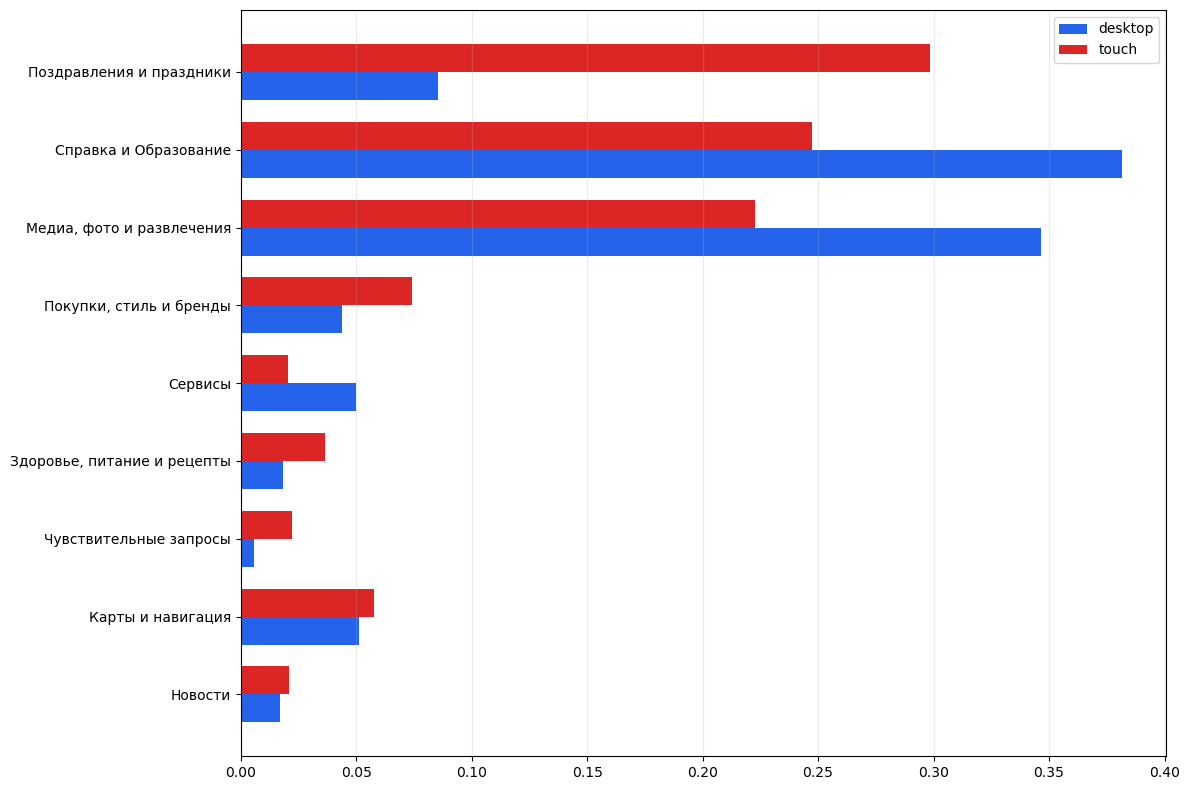

,theme,total_count,theme_query_total,share_gap,dominant_platform,platform,platform_total,theme_share_of_platform
0,Поздравления и праздники,57413,6288,0.2131,touch,desktop,73575,0.0855
9,Поздравления и праздники,57413,51125,0.2131,touch,touch,171236,0.2986
1,Справка и Образование,70414,28080,0.1345,desktop,desktop,73575,0.3817
10,Справка и Образование,70414,42334,0.1345,desktop,touch,171236,0.2472
2,"Медиа, фото и развлечения",63597,25496,0.1240,desktop,desktop,73575,0.3465
11,"Медиа, фото и развлечения",63597,38101,0.1240,desktop,touch,171236,0.2225
3,"Покупки, стиль и бренды",15900,3220,0.0302,touch,desktop,73575,0.0438
12,"Покупки, стиль и бренды",15900,12680,0.0302,touch,touch,171236,0.0740
4,Сервисы,7180,3686,0.0297,desktop,desktop,73575,0.0501
13,Сервисы,7180,3494,0.0297,desktop,touch,171236,0.0204


In [26]:
theme_contrast = (
    categorized_frequent_queries
    .groupby('theme', as_index=False)
    .agg(
        total_count=('total_count', 'sum'),
        desktop_count=('desktop_count', 'sum'),
        touch_count=('touch_count', 'sum')
    )
)

desktop_total = int(categorized_frequent_queries['desktop_count'].sum())
touch_total = int(categorized_frequent_queries['touch_count'].sum())

theme_contrast['desktop_share'] = (theme_contrast['desktop_count'] / desktop_total).round(4)
theme_contrast['touch_share'] = (theme_contrast['touch_count'] / touch_total).round(4)
theme_contrast['share_gap'] = (theme_contrast['touch_share'] - theme_contrast['desktop_share']).abs().round(4)
theme_contrast['dominant_platform'] = np.where(
    theme_contrast['touch_share'] > theme_contrast['desktop_share'],
    'touch',
    'desktop'
)

theme_contrast = theme_contrast.sort_values(['share_gap', 'total_count'], ascending=[False, False])

datalens_grouped_data = pd.concat([
    theme_contrast[[
        'theme', 'total_count', 'desktop_count', 'share_gap', 'dominant_platform'
    ]].rename(columns={
        'desktop_count': 'theme_query_total'
    }).assign(
        platform='desktop',
        platform_total=desktop_total,
        theme_share_of_platform=lambda x: x['theme_query_total'] / x['platform_total']
    ),
    theme_contrast[[
        'theme', 'total_count', 'touch_count', 'share_gap', 'dominant_platform'
    ]].rename(columns={
        'touch_count': 'theme_query_total'
    }).assign(
        platform='touch',
        platform_total=touch_total,
        theme_share_of_platform=lambda x: x['theme_query_total'] / x['platform_total']
    )
], ignore_index=True)

datalens_grouped_data['theme_share_of_platform'] = datalens_grouped_data['theme_share_of_platform'].round(4)
datalens_grouped_data = datalens_grouped_data.sort_values(['share_gap', 'theme', 'platform'], ascending=[False, True, True])
datalens_grouped_data.to_csv('datalens_grouped_data.csv', index=False, encoding='utf-8-sig')

plot_df = theme_contrast.sort_values('share_gap', ascending=True).copy()

y = np.arange(len(plot_df))
bar_h = 0.36

plt.figure(figsize=(12, 8))
plt.barh(
    y - bar_h / 2,
    plot_df['desktop_share'],
    height=bar_h,
    label='desktop',
    color='#2563eb'
)
plt.barh(
    y + bar_h / 2,
    plot_df['touch_share'],
    height=bar_h,
    label='touch',
    color='#dc2626'
)

plt.yticks(y, plot_df['theme'])
plt.grid(axis='x', alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

datalens_grouped_data


# Общий вывод
**Гипотеза подтвердилась:**

Интересы пользователей поиска по картинкам на desktop и touch заметно различаются

В наиболее частотной части трафика desktop сильнее связан с учебными, рабочими и справочными сценариями, а touch — с поздравлениями, развлечениями и быстрыми повседневными задачами

### Датасет для графика по часам

In [29]:
theme_time_data = (
    categorized_frequent_queries_daily
    .groupby(['date', 'week_start', 'day_of_week', 'hour', 'platform', 'theme'], as_index=False)
    .agg(query_count=('query_count', 'sum'))
    .sort_values(['date', 'hour', 'theme', 'platform'])
)

theme_time_data.to_csv('datalens_theme_time_data.csv', index=False, encoding='utf-8-sig')
theme_time_data.head()

platform_daily_totals = (
    theme_time_data
    .groupby(['date', 'platform'], as_index=False)
    .agg(platform_day_total=('query_count', 'sum'))
)

hourly_pattern = pd.merge(
    theme_time_data,
    platform_daily_totals,
    on=['date', 'platform'],
    how='left'
)

hourly_pattern['query_share_in_platform_day_hour'] = (
    hourly_pattern['query_count'] / hourly_pattern['platform_day_total']
).round(4)

hourly_pattern_avg = (
    hourly_pattern
    .groupby(['hour', 'platform', 'theme'], as_index=False)
    .agg(avg_query_share_in_platform_day_hour=('query_share_in_platform_day_hour', 'mean'))
    .sort_values(['theme', 'platform', 'hour'])
)

hourly_pattern_avg.to_csv('datalens_hourly_pattern.csv', index=False, encoding='utf-8-sig')
hourly_pattern_avg.head()

,hour,platform,theme,avg_query_share_in_platform_day_hour
0,0,desktop,"Здоровье, питание и рецепты",0.000683
18,1,desktop,"Здоровье, питание и рецепты",0.000480
36,2,desktop,"Здоровье, питание и рецепты",0.000330
54,3,desktop,"Здоровье, питание и рецепты",0.000367
72,4,desktop,"Здоровье, питание и рецепты",0.000382


### Датасет для графика по неделям

In [31]:
weekday_counts = (
    theme_time_data
    .groupby(['day_of_week', 'platform', 'theme'], as_index=False)
    .agg(query_count=('query_count', 'sum'))
)

platform_period_totals = (
    theme_time_data
    .groupby(['platform'], as_index=False)
    .agg(platform_period_total=('query_count', 'sum'))
)

weekly_pattern_avg = pd.merge(
    weekday_counts,
    platform_period_totals,
    on='platform',
    how='left'
)

weekly_pattern_avg['avg_query_share_in_platform_weekday'] = (
    weekly_pattern_avg['query_count'] / weekly_pattern_avg['platform_period_total']
).round(4)

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekly_pattern_avg['day_of_week'] = pd.Categorical(
    weekly_pattern_avg['day_of_week'],
    categories=day_order,
    ordered=True
)

weekly_pattern_avg = weekly_pattern_avg.sort_values(['theme', 'platform', 'day_of_week'])
weekly_pattern_avg.to_csv('datalens_weekly_pattern.csv', index=False, encoding='utf-8-sig')
weekly_pattern_avg.head(14)

,day_of_week,platform,theme,query_count,platform_period_total,avg_query_share_in_platform_weekday
18,Monday,desktop,"Здоровье, питание и рецепты",180,73592,0.0024
90,Tuesday,desktop,"Здоровье, питание и рецепты",198,73592,0.0027
108,Wednesday,desktop,"Здоровье, питание и рецепты",192,73592,0.0026
72,Thursday,desktop,"Здоровье, питание и рецепты",200,73592,0.0027
0,Friday,desktop,"Здоровье, питание и рецепты",187,73592,0.0025
36,Saturday,desktop,"Здоровье, питание и рецепты",181,73592,0.0025
54,Sunday,desktop,"Здоровье, питание и рецепты",199,73592,0.0027
27,Monday,touch,"Здоровье, питание и рецепты",879,171298,0.0051
99,Tuesday,touch,"Здоровье, питание и рецепты",879,171298,0.0051
117,Wednesday,touch,"Здоровье, питание и рецепты",902,171298,0.0053
